# TCN Classifier — Clasificación de Audio Raw (Parkinson)

Clasificación binaria **Control vs Patológicas** usando una **Temporal Convolutional Network (TCN)**
con activación WaveNet (tanh × sigmoid) aplicada directamente sobre la forma de onda.


- **Modelo original**: (https://www.kaggle.com/code/christofhenkel/temporal-convolutional-network)
---
## ¿Qué es un TCN y cómo funciona?

Un TCN es una red convolucional 1D con tres propiedades clave:

| Propiedad | Detalle |
|---|---|
| **Causalidad** | Padding `causal`: el modelo sólo ve el pasado, nunca el futuro |
| **Dilatación exponencial** | Cada bloque usa `dilation_rate = 2^k`, aumentando el campo receptivo sin más parámetros |
| **Conexiones residuales** | `salida = entrada + f(entrada)`, como ResNet, facilita el entrenamiento profundo |

### Activación WaveNet (gated activation)
```
gate = tanh(Conv1D_tanh(x))  ×  sigmoid(Conv1D_sigm(x))
```
- La rama **tanh** modula el *contenido* (valores entre −1 y 1)
- La rama **sigmoid** actúa como *puerta* (valores entre 0 y 1, controla cuánta información pasa)
- Permite al modelo aprender patrones temporales complejos similares a una LSTM, pero paralelizable.

### Campo receptivo efectivo
```
RF = 1 + (kernel_size − 1) × Σ(dilations) × nb_stacks
```
Con `kernel_size=3, dilations=[1,2,4,8,16,32], nb_stacks=1`:
```
RF = 1 + 2 × 63 × 1 = 127 muestras ≈ 7.9 ms @ 16 kHz
```
Con `nb_stacks=2` → RF = 253 muestras ≈ 15.8 ms.

### Arquitectura completa
```
Audio (8000,)
  → Reshape (8000, 1)
  → Conv1D 1×1  [proyección: 1 → nb_filters canales]
  → Bloque residual (dilation=1)   ──► skip_1
  → Bloque residual (dilation=2)   ──► skip_2
  → Bloque residual (dilation=4)   ──► skip_3
  → ...                             ...
  → Add(skip_1, skip_2, ...) → ReLU
  → GlobalAvgPool + GlobalMaxPool → Concat
  → Dense(32, relu) → Dropout
  → Dense(2, softmax)  [Control | Patológicas]
```

- **Modelo**: `src/models/TCNClassifier.py`
- **Splits**: Subject-wise K-Fold desde `data_splits.json`

In [146]:
import os
import sys
import json
import numpy as np
import librosa
from pathlib import Path
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, ConfusionMatrixDisplay, RocCurveDisplay)
import matplotlib.pyplot as plt


# ── Detectar raíz del proyecto ────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'data').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
print(f"PROJECT_ROOT: {PROJECT_ROOT}")

# ── Importar TCNClassifier ────────────────────────────────────────────────────
sys.path.insert(0, str(PROJECT_ROOT / 'src' / 'models'))
from TCNClassifier import TCNClassifier

print(f"TensorFlow: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

PROJECT_ROOT: c:\Users\julia\LOCAL_JULIA\PROYECTOS GIT\TFM-Data-Science
TensorFlow: 2.21.0
GPU disponible: []


In [147]:
# ============================================================
# ────────────────────────────INPUT────────────────────────────
# Frecuencia de muetreo (sample Rate) del input
# ============================================================

# Ruta base donde tienes los audios cortados
DATA_DIR = '../../data/processed'

# Cogemos un archivo cualquiera de muestra del primer fold
archivo_muestra = folds[0]['train_files'][0]

# Si el json no guardó la ruta completa, se la añadimos
if not os.path.exists(archivo_muestra):
    archivo_muestra = os.path.join(DATA_DIR, archivo_muestra)

# =====================================================================
# 2. ANÁLISIS DE LA FRECUENCIA DE MUESTRE ORIGINAL

# Leemos el archivo original tal cual, SIN comprimir, para ver su anatomía
audio_original, sr_original = librosa.load(archivo_muestra, sr=None)
duracion_real_segundos = len(audio_original) / sr_original

# =====================================================================
# 3. AUTO-CONFIGURACIÓN 

TARGET_SR = 16000  # Pon la resolución a la que quieras probar el modelo (8000, 16000, 22000...)

# La fórmula que calcula el tamaño de la matriz
TARGET_SAMPLES = int(np.ceil(duracion_real_segundos * TARGET_SR))

print("=== 1. ANÁLISIS DEL DATASET REAL ===")
print(f"Archivo analizado      : {os.path.basename(archivo_muestra)}")
print(f"Resolución original    : {sr_original} Hz")
print(f"Duración exacta        : {duracion_real_segundos:.5f} segundos")
print("\n=== 2. CONFIGURACIÓN CALCULADA PARA EL MODELO ===")
print(f"Tu TARGET_SR elegido   : {TARGET_SR} Hz")
print(f"TARGET_SAMPLES exacto  : {TARGET_SAMPLES} valores")
print("=================================================")


=== 1. ANÁLISIS DEL DATASET REAL ===
Archivo analizado      : AVPEPUDEAC0003a1.wav
Resolución original    : 22050 Hz
Duración exacta        : 0.48893 segundos

=== 2. CONFIGURACIÓN CALCULADA PARA EL MODELO ===
Tu TARGET_SR elegido   : 16000 Hz
TARGET_SAMPLES exacto  : 7823 valores


## 1. Hiperparámetros

In [148]:
# ============================================================
#  HIPERPARÁMETROS — Modifica aquí para experimentar
# ============================================================

DATASET_NAME = 'pc-gita'   # 'neurovoz' o 'pc-gita'
FOLD_IDX     = 4            # Fold a evaluar (0..K-1)


# ──────────────────────────── 1. TRAINING PARAMETERS ─────────────────────────
BATCH_SIZE     = 8       # REDUCIDO A 8: Para que la memoria no explote al aumentar la resolución
EPOCHS         = 50
PATIENCE       = 15
OPTIMIZER      = tf.keras.optimizers.Adam(learning_rate=1e-3)
NUM_CLASSES    = 2
OPTIMIZER  = 'adam'


# ──────────────────────────── 2. TCN ARCHITECTURE ────────────────────────
NB_FILTERS     = 64      # Puedes subirlo a 128 si ves que el PC va sobrado y quieres más potencia
KERNEL_SIZE    = 5
NB_STACKS      = 2
DROPOUT_RATE   = 0.3

# DILATIONS    = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 825]  # RF = 1 + 2×255 = 511 muestras ≈ 64 ms
# DENSE_UNITS  = 32


In [149]:
# =========================================================================
# 3. AUTO-CÁLCULO DE DILATACIONES (EL SEGURO ANTI-FALLOS)
# =========================================================================
# El código mirará el TARGET_SAMPLES que se calculó en la celda de arriba
# y añadirá dilataciones (1, 2, 4, 8, 16...) hasta cubrir todo el audio.
required_sum = (TARGET_SAMPLES - 1) / ((KERNEL_SIZE - 1) * NB_STACKS)

DILATIONS = []
current_sum = 0
d = 1
while current_sum < required_sum:
    DILATIONS.append(d)
    current_sum += d
    d *= 2

receptive_field = 1 + (KERNEL_SIZE - 1) * NB_STACKS * sum(DILATIONS)

print(f"--- PARÁMETROS TCN AUTOCONFIGURADOS ---")
print(f"Batch Size (Lote)    : {BATCH_SIZE} audios por pasada")
print(f"Vector de Entrada    : {TARGET_SAMPLES} números por audio")
print(f"Lista de Dilataciones: {DILATIONS}")
print(f"Campo Receptivo Real : {receptive_field} (Cubriendo todo el audio: OK)")
print(f"  Campo receptivo:  {RF} muestras ≈ {RF_ms:.1f} ms @ {TARGET_SR} Hz")
print(f"---------------------------------------")


--- PARÁMETROS TCN AUTOCONFIGURADOS ---
Batch Size (Lote)    : 8 audios por pasada
Vector de Entrada    : 7823 números por audio
Lista de Dilataciones: [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]
Campo Receptivo Real : 8185 (Cubriendo todo el audio: OK)
  Campo receptivo:  8185 muestras ≈ 511.6 ms @ 16000 Hz
---------------------------------------


In [150]:
print(DILATIONS)

[1, 2, 4, 8, 16, 32, 64, 128, 256, 512]


In [151]:
# ── Rutas ─────────────────────────────────────────────────────
DATA_DIR    = PROJECT_ROOT / 'data' / 'processed'
SPLITS_FILE = PROJECT_ROOT / 'data' / 'data_splits.json'

# ── Cálculo del campo receptivo ──────────────────────────────
RF = 1 + (KERNEL_SIZE - 1) * sum(DILATIONS) * NB_STACKS
RF_ms = RF / TARGET_SR * 1000

DATASET_NAME = 'pc-gita'

print("Configuración:")
print(f"  Dataset:          {DATASET_NAME}")
# print(f"  SR original:      {ORIGINAL_SR} Hz")
# print(f"  SR del modelo:    {TARGET_SR} Hz")
print(f"  Target samples:   {TARGET_SAMPLES} ({TARGET_SAMPLES/TARGET_SR*1000:.0f} ms)")
print(f"  input_shape:      ({TARGET_SAMPLES},)")
print(f"  TCN nb_filters:   {NB_FILTERS}")
print(f"  TCN kernel_size:  {KERNEL_SIZE}")
print(f"  TCN dilations:    {DILATIONS}")
print(f"  TCN nb_stacks:    {NB_STACKS}")
print(f"  Campo receptivo:  {RF} muestras ≈ {RF_ms:.1f} ms @ {TARGET_SR} Hz")

Configuración:
  Dataset:          pc-gita
  Target samples:   7823 (489 ms)
  input_shape:      (7823,)
  TCN nb_filters:   64
  TCN kernel_size:  5
  TCN dilations:    [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]
  TCN nb_stacks:    2
  Campo receptivo:  8185 muestras ≈ 511.6 ms @ 16000 Hz


## 2. Carga de Splits y Audio

Se reutiliza exactamente la misma lógica de carga que en `wavenet.ipynb`:
- Resample de 22050 Hz → 16000 Hz con `librosa.load(sr=TARGET_SR)`
- Pad con ceros o crop a `TARGET_SAMPLES` muestras
- Etiqueta: `1` si `'Patologicas'` aparece en la ruta, `0` si no

In [152]:
# Cargar JSON de splits
with open(SPLITS_FILE, 'r') as f:
    all_splits = json.load(f)

folds = all_splits[DATASET_NAME]
K     = all_splits['metadata']['K_folds']
print(f"Dataset: {DATASET_NAME} | K={K} folds disponibles")

Dataset: pc-gita | K=5 folds disponibles


In [153]:
def load_audio_files(file_list, data_dir, target_sr, target_samples):
    """
    Carga, resamplea y normaliza una lista de audios.

    Returns
    -------
    X : np.ndarray, shape (N, target_samples)   — formas de onda
    y : np.ndarray, shape (N,)                  — etiquetas (0/1)
    """
    waveforms, labels = [], []
    skipped = 0

    for rel_path in tqdm(file_list, desc='Cargando audios', leave=False):
        rel_path_clean = rel_path.replace('\\', os.sep).replace('/', os.sep)
        full_path = data_dir / rel_path_clean

        if not full_path.exists():
            skipped += 1
            continue

        # Carga con resample al vuelo
        y_audio, _ = librosa.load(full_path, sr=target_sr)

        # Pad o crop
        if len(y_audio) >= target_samples:
            y_audio = y_audio[:target_samples]
        else:
            y_audio = np.pad(y_audio, (0, target_samples - len(y_audio)))

        waveforms.append(y_audio)
        labels.append(1 if 'Patologicas' in rel_path else 0)

    if skipped:
        print(f"  ⚠ {skipped} archivos no encontrados y omitidos")

    return np.array(waveforms, dtype=np.float32), np.array(labels, dtype=np.int32)


def load_fold_data(fold_dict, data_dir, target_sr, target_samples):
    """Carga train, val y test de un fold."""
    print("Cargando TRAIN...")
    X_tr, y_tr = load_audio_files(fold_dict['train_files'], data_dir, target_sr, target_samples)
    print(f"  X_train: {X_tr.shape}  (HC={np.sum(y_tr==0)}, PA={np.sum(y_tr==1)})")

    print("Cargando TEST...")
    X_te, y_te = load_audio_files(fold_dict['test_files'], data_dir, target_sr, target_samples)
    print(f"  X_test:  {X_te.shape}  (HC={np.sum(y_te==0)}, PA={np.sum(y_te==1)})")

    return X_tr, y_tr, X_te, y_te

In [154]:
fold_data = folds[FOLD_IDX]

print(f"--- ARCHIVOS EN TRAIN (Total: {len(fold_data['train_files'])} audios) ---")
for f in fold_data['train_files'][:10]:
    print(f)
print('... (mostrando solo los primeros 10)')

print(f"\n--- ARCHIVOS EN TEST (Total: {len(fold_data['test_files'])} audios) ---")
for f in fold_data['test_files'][:10]:
    print(f)
print('... (mostrando solo los primeros 10)')

--- ARCHIVOS EN TRAIN (Total: 480 audios) ---
pc-gita\Control\A\AVPEPUDEAC0017a1.wav
pc-gita\Control\A\AVPEPUDEAC0017a2.wav
pc-gita\Control\A\AVPEPUDEAC0017a3.wav
pc-gita\Control\E\AVPEPUDEAC0017e1.wav
pc-gita\Control\E\AVPEPUDEAC0017e2.wav
pc-gita\Control\E\AVPEPUDEAC0017e3.wav
pc-gita\Control\A\AVPEPUDEAC0024a1.wav
pc-gita\Control\A\AVPEPUDEAC0024a2.wav
pc-gita\Control\A\AVPEPUDEAC0024a3.wav
pc-gita\Control\E\AVPEPUDEAC0024e1.wav
... (mostrando solo los primeros 10)

--- ARCHIVOS EN TEST (Total: 120 audios) ---
pc-gita\Control\A\AVPEPUDEAC0040a1.wav
pc-gita\Control\A\AVPEPUDEAC0040a2.wav
pc-gita\Control\A\AVPEPUDEAC0040a3.wav
pc-gita\Control\E\AVPEPUDEAC0040e1.wav
pc-gita\Control\E\AVPEPUDEAC0040e2.wav
pc-gita\Control\E\AVPEPUDEAC0040e3.wav
pc-gita\Control\A\AVPEPUDEAC0004a1.wav
pc-gita\Control\A\AVPEPUDEAC0004a2.wav
pc-gita\Control\A\AVPEPUDEAC0004a3.wav
pc-gita\Control\E\AVPEPUDEAC0004e1.wav
... (mostrando solo los primeros 10)


Separamos dentro de train, un subgrupo para poder ir validando y elegir parametros, luego el modelo se volvera a enrenar incluyendo la validation en train para sacar las metricas de test

In [155]:
# Cargar el fold seleccionado
fold_data = folds[FOLD_IDX]

# -------------------------------------------------------------
# CORRECCIÓN: Dividir los archivos de Train en Train y Valid POR SUJETO (ESTRATIFICADO)
# -------------------------------------------------------------
import re
from sklearn.model_selection import GroupShuffleSplit

train_files = fold_data['train_files']

# Extraer el ID del sujeto de cada archivo para evitar Data Leakage
def get_subject(f):
    filename = f.replace('\\', '/').split('/')[-1]
    if 'AVPEPUDEA' in filename.upper():
        return re.sub(r'[aeiou]\d+\.wav$', '', filename.lower())
    else:
        return filename.split('-')[0]

# Separar audios sanos y audios enfermos, y sus respectivos IDs (grupos) basándonos en la ruta
hc_files, hc_groups = [], []
pa_files, pa_groups = [], []

for f in train_files:
    subj = get_subject(f)
    if 'Control' in f:
        hc_files.append(f)
        hc_groups.append(subj)
    else:
        pa_files.append(f)
        pa_groups.append(subj)

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)

# Dividir sanos (dejando el 25% de los pacientes sanos para Valid)
hc_train_idx, hc_val_idx = next(gss.split(hc_files, groups=hc_groups))
val_files_hc = [hc_files[i] for i in hc_val_idx]
train_files_hc = [hc_files[i] for i in hc_train_idx]

# Dividir enfermos (dejando el 25% de los pacientes enfermos para Valid)
pa_train_idx, pa_val_idx = next(gss.split(pa_files, groups=pa_groups))
val_files_pa = [pa_files[i] for i in pa_val_idx]
train_files_pa = [pa_files[i] for i in pa_train_idx]

# Juntamos los archivos finales para Train y Valid
val_files = val_files_hc + val_files_pa
train_files_new = train_files_hc + train_files_pa

# Mezclamos un poco para que no entren todos los sanos de golpe y luego todos los enfermos
import random
random.seed(42)
random.shuffle(val_files)
random.shuffle(train_files_new)


# -------------------------------------------------------------
# ---- IMPRIMIR LOS ARCHIVOS PARA VERIFICAR ----

print(f"\n--- ARCHIVOS EN TRAIN PURO (Total: {len(train_files_new)} audios) ---")
for idx, f in enumerate(train_files_new[:10]):
    print(f"Train {idx+1}: {f}")
print("... (truncado)")

print(f"\n--- ARCHIVOS EN VALIDATION (Total: {len(val_files)} audios) ---")
for idx, f in enumerate(val_files[:10]):
    print(f"Val {idx+1}: {f}")
print("... (truncado)")

print(f"\n--- ARCHIVOS EN TEST (Total: {len(fold_data['test_files'])} audios) ---")
for idx, f in enumerate(fold_data['test_files'][:10]):
    print(f"Test {idx+1}: {f}")
print("... (truncado)")
# ----------------------------------------------


--- ARCHIVOS EN TRAIN PURO (Total: 360 audios) ---
Train 1: pc-gita\Patologicas\E\AVPEPUDEA0056e2.wav
Train 2: pc-gita\Patologicas\A\AVPEPUDEA0041a1.wav
Train 3: pc-gita\Control\A\AVPEPUDEAC0020a3.wav
Train 4: pc-gita\Control\A\AVPEPUDEAC0015a3.wav
Train 5: pc-gita\Patologicas\E\AVPEPUDEA0054e1.wav
Train 6: pc-gita\Patologicas\A\AVPEPUDEA0020a3.wav
Train 7: pc-gita\Control\A\AVPEPUDEAC0052a3.wav
Train 8: pc-gita\Control\E\AVPEPUDEAC0015e1.wav
Train 9: pc-gita\Control\E\AVPEPUDEAC0007e2.wav
Train 10: pc-gita\Control\A\AVPEPUDEAC0042a1.wav
... (truncado)

--- ARCHIVOS EN VALIDATION (Total: 120 audios) ---
Val 1: pc-gita\Control\E\AVPEPUDEAC0041e1.wav
Val 2: pc-gita\Patologicas\A\AVPEPUDEA0047a1.wav
Val 3: pc-gita\Patologicas\E\AVPEPUDEA0027e3.wav
Val 4: pc-gita\Patologicas\A\AVPEPUDEA0059a1.wav
Val 5: pc-gita\Patologicas\A\AVPEPUDEA0027a3.wav
Val 6: pc-gita\Control\A\AVPEPUDEAC0057a1.wav
Val 7: pc-gita\Patologicas\E\AVPEPUDEA0027e1.wav
Val 8: pc-gita\Patologicas\E\AVPEPUDEA0047e1.wav
Va

In [156]:
# Cargar los audios ya separados limpiamente
print("\nCargando TRAIN...")
X_train, y_train_raw = load_audio_files(train_files_new, DATA_DIR, TARGET_SR, TARGET_SAMPLES)
print(f"  X_train: {X_train.shape}  (HC={np.sum(y_train_raw==0)}, PA={np.sum(y_train_raw==1)})")

print("\nCargando VAL...")
X_val, y_val_raw = load_audio_files(val_files, DATA_DIR, TARGET_SR, TARGET_SAMPLES)
print(f"  X_val:   {X_val.shape}  (HC={np.sum(y_val_raw==0)}, PA={np.sum(y_val_raw==1)})")

print("\nCargando TEST...")
X_test, y_test_raw = load_audio_files(fold_data['test_files'], DATA_DIR, TARGET_SR, TARGET_SAMPLES)
print(f"  X_test:  {X_test.shape}  (HC={np.sum(y_test_raw==0)}, PA={np.sum(y_test_raw==1)})")

# One-hot encoding para Keras (loss=categorical_crossentropy)
y_train = to_categorical(y_train_raw, NUM_CLASSES)
y_val   = to_categorical(y_val_raw,   NUM_CLASSES)

print(f"\nShapes finales:")
print(f"  X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape}    y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape}   y_test:  {y_test_raw.shape}")



Cargando TRAIN...


  X_train: (360, 7823)  (HC=180, PA=180)

Cargando VAL...


  X_val:   (120, 7823)  (HC=60, PA=60)

Cargando TEST...


  X_test:  (120, 7823)  (HC=60, PA=60)

Shapes finales:
  X_train: (360, 7823)  y_train: (360, 2)
  X_val:   (120, 7823)    y_val:   (120, 2)
  X_test:  (120, 7823)   y_test:  (120,)


## 3. Construir el Modelo TCN

In [157]:
clf = TCNClassifier(
    input_shape  = (TARGET_SAMPLES,),
    n_classes    = NUM_CLASSES,
    nb_filters   = NB_FILTERS,
    kernel_size  = KERNEL_SIZE,
    dilations    = DILATIONS,
    nb_stacks    = NB_STACKS,
    dropout_rate = DROPOUT_RATE,
    dense_units  = DENSE_UNITS,
    padding      = 'causal',
    name         = 'tcn_parkinson',
)

print(clf.receptive_field_info())
# clf.model.summary()

Campo receptivo: 8185 muestras ≈ 511.6 ms @ 16 kHz


## 4. Compilar el Modelo

In [158]:
clf.model.compile(
    optimizer = OPTIMIZER,
    loss      = tf.keras.losses.CategoricalCrossentropy(),
    metrics   = ['accuracy'],
)
print("Modelo compilado ✓")

Modelo compilado ✓


## 5. Entrenamiento

Se usan dos callbacks estándar:
- **EarlyStopping**: para si la val_loss no mejora durante `patience` epochs
- **ReduceLROnPlateau**: reduce el learning rate × 0.5 si no mejora en 5 epochs

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=15,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1,
)

callbacks = [early_stopping, reduce_lr]

print("=== FASE 1: BÚSQUEDA DE HIPERPARÁMETROS (60% Train / 20% Val) ===")
history = clf.model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    shuffle         = True,
    callbacks       = callbacks,
)


=== FASE 1: BÚSQUEDA DE HIPERPARÁMETROS (60% Train / 20% Val) ===
Epoch 1/50


KeyboardInterrupt: 

## 6. Curvas de Aprendizaje

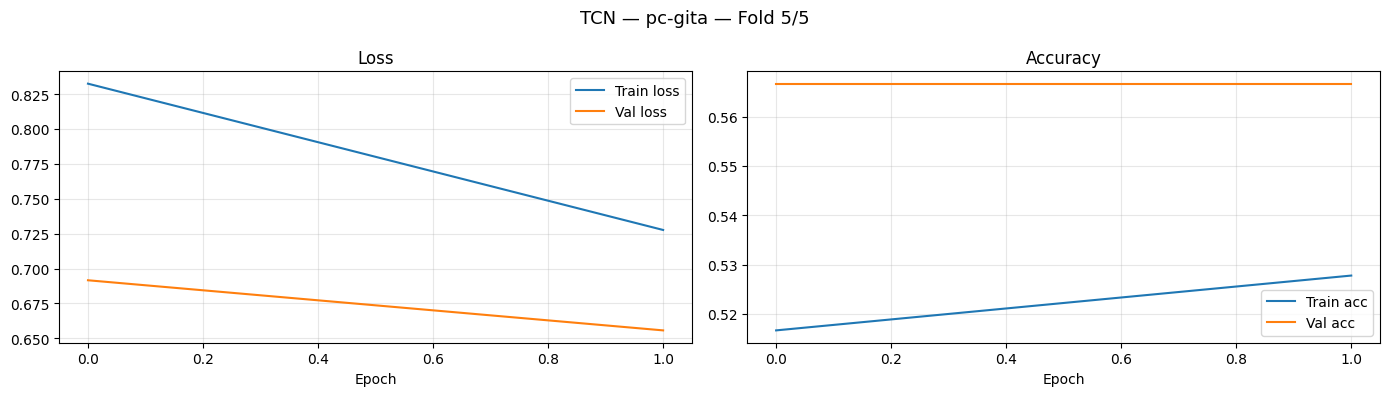

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Pérdida
axes[0].plot(history.history['loss'],     label='Train loss')
axes[0].plot(history.history['val_loss'], label='Val loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'],     label='Train acc')
axes[1].plot(history.history['val_accuracy'], label='Val acc')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'TCN — {DATASET_NAME} — Fold {FOLD_IDX+1}/{K}', fontsize=13)
plt.tight_layout()
plt.show()

## Evaluación en Validation

In [ ]:
# -------------------------------------------------------------
# EVALUACIÓN EN VALIDACIÓN (Resultados de la Fase 1)
# -------------------------------------------------------------
from sklearn.metrics import accuracy_score

# Hacemos las predicciones usando el modelo de la Fase 1 (clf) sobre el set X_val
y_val_pred_proba = clf.model.predict(X_val, batch_size=BATCH_SIZE)
y_val_pred = np.argmax(y_val_pred_proba, axis=1)

# Calculamos el accuracy usando las etiquetas originales sin One-Hot Encoding (y_val_raw)
acc_val = accuracy_score(y_val_raw, y_val_pred)

print(f"{'='*50}")
print(f" RESULTADOS — Fase 1 (Validación)")
print(f"{'='*50}")
print(f"  Accuracy (Validación) : {acc_val:.4f}")


4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step
 RESULTADOS — Fase 1 (Validación)
  Accuracy (Validación) : 0.5667


## 7. Reentrenamiento Final con el 80% (Opción Académica)\n

Una vez terminada la Fase 1, sabemos cuál ha sido la **mejor época** gracias al Early Stopping. \n
Ahora procedemos a:\n
1. Juntar `X_train` y `X_val` para formar nuestro 80% completo.\n
2. Crear un modelo TCN nuevo desde cero.\n
3. Entrenarlo sin validación durante exactamente ese número de épocas.\n
4. Evaluar ese modelo final en el conjunto de Test (20%).

In [ ]:
# Calcular la mejor época de la Fase 1\n
if early_stopping.stopped_epoch > 0:
    best_epoch = early_stopping.stopped_epoch - early_stopping.patience + 1
else:
    best_epoch = np.argmax(history.history['val_accuracy']) + 1

print(f"\nLa mejor época en la Fase 1 fue la: {best_epoch}")
print("=== FASE 2: REENTRENAMIENTO FINAL (80% Train Puro) ===")

# 1. Unir Train y Val para crear el Train Completo (80%)\n
import numpy as np
X_train_full = np.concatenate([X_train, X_val], axis=0)
y_train_full = np.concatenate([y_train, y_val], axis=0)

print(f"  X_train_full shape: {X_train_full.shape}")


# 2. Crear un modelo completamente nuevo\n
clf_final = TCNClassifier(
    input_shape  = (TARGET_SAMPLES,),
    n_classes    = NUM_CLASSES,
    nb_filters   = NB_FILTERS,
    kernel_size  = KERNEL_SIZE,
    dilations    = DILATIONS,
    nb_stacks    = NB_STACKS,
    dropout_rate = DROPOUT_RATE,
    dense_units  = DENSE_UNITS,
    padding      = 'causal',
    name         = 'tcn_parkinson_final',
)


clf_final.model.compile(
    optimizer = OPTIMIZER,
    loss      = tf.keras.losses.CategoricalCrossentropy(),
    metrics   = ['accuracy'],
)


# 3. Entrenar el modelo final durante las épocas exactas obtenidas\n
history_final = clf_final.model.fit(
    X_train_full, y_train_full,
    epochs          = best_epoch,
    batch_size      = BATCH_SIZE,
    shuffle         = True,
    verbose         = 1
)
print("\n¡Modelo Final Entrenado con el 80% de los datos!")


La mejor época en la Fase 1 fue la: 1
=== FASE 2: REENTRENAMIENTO FINAL (80% Train Puro) ===
  X_train_full shape: (480, 4000)
15/15 ━━━━━━━━━━━━━━━━━━━━ 123s 3s/step - accuracy: 0.5208 - loss: 0.7496

¡Modelo Final Entrenado con el 80% de los datos!


### Metricas por instancia/audio

In [ ]:
# Predicciones con el modelo final (entrenado con el 80%)
y_pred_proba = clf_final.model.predict(X_test, batch_size=BATCH_SIZE)  # shape (N, 2)
y_pred       = np.argmax(y_pred_proba, axis=1)             # clase predicha
y_true       = y_test_raw                                  # entero (0/1)

# Métricas
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
acc = accuracy_score(y_true, y_pred)
roc = roc_auc_score(y_true, y_pred_proba[:, 1])

print(f"{'='*50}")
print(f" RESULTADOS — Fase 2 (Test Final)")
print(f"{'='*50}")
print(f"  Accuracy : {acc:.4f}")
print(f"  ROC-AUC  : {roc:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=['Control', 'Patológicas']))


4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step
 RESULTADOS — Fase 2 (Test Final)
  Accuracy : 0.5000
  ROC-AUC  : 0.5392

              precision    recall  f1-score   support

     Control       0.00      0.00      0.00        60
 Patológicas       0.50      1.00      0.67        60

    accuracy                           0.50       120
   macro avg       0.25      0.50      0.33       120
weighted avg       0.25      0.50      0.33       120



c:\Users\julia\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\julia\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\julia\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

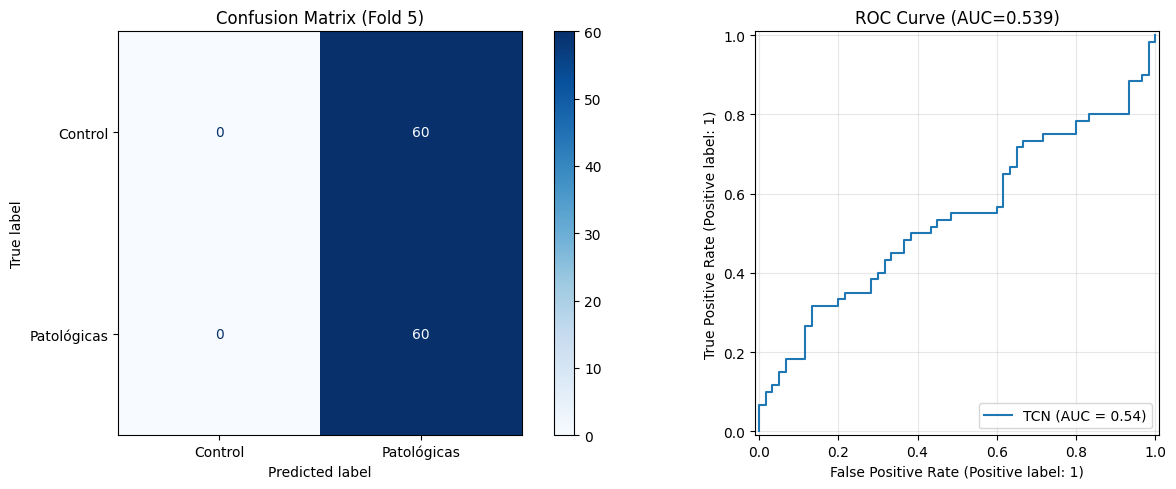

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm   = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Control', 'Patológicas'])
disp.plot(ax=axes[0], cmap='Blues')
axes[0].set_title(f'Confusion Matrix (Fold {FOLD_IDX+1})')

# ROC Curve
RocCurveDisplay.from_predictions(
    y_true, y_pred_proba[:, 1],
    name='TCN',
    ax=axes[1],
)
axes[1].set_title(f'ROC Curve (AUC={roc:.3f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Metricas por paciente

In [ ]:
# -------------------------------------------------------------
# 9. EVALUACIÓN POR PACIENTE (SUBJECT-LEVEL / MAJORITY VOTING)
# -------------------------------------------------------------
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

test_files = fold_data['test_files']

# 1. Agrupar las probabilidades predichas por paciente
patient_preds = {}
patient_trues = {}

for i, f in enumerate(test_files):
    subj = get_subject(f)
    
    # Inicializar el paciente en el diccionario si es la primera vez que lo leemos
    if subj not in patient_preds:
        patient_preds[subj] = []
        # La etiqueta real (0 o 1) siempre es idéntica para todos los audios del mismo paciente
        patient_trues[subj] = y_true[i] 
        
    # Guardar la probabilidad que la red predijo para la clase Patológica (clase 1)
    patient_preds[subj].append(y_pred_proba[i, 1])

# 2. Hacer el Voto Mayoritario (Media de las probabilidades de sus audios)
y_true_patient = []
y_pred_proba_patient = []
y_pred_patient = []

for subj in patient_preds.keys():
    y_true_patient.append(patient_trues[subj])
    
    # Calcular la media de las probabilidades de todos los audios de este paciente
    mean_proba = np.mean(patient_preds[subj])
    y_pred_proba_patient.append(mean_proba)
    
    # Si la media supera el 50% de probabilidad, el paciente se diagnostica como Patológico
    if mean_proba >= 0.5:
        y_pred_patient.append(1)
    else:
        y_pred_patient.append(0)

# 3. Calcular las métricas a nivel de paciente
acc_subj = accuracy_score(y_true_patient, y_pred_patient)
roc_subj = roc_auc_score(y_true_patient, y_pred_proba_patient)

print(f"{'='*50}")
print(f" RESULTADOS A NIVEL DE PACIENTE (Majority Voting)")
print(f"{'='*50}")
print(f"  Total Pacientes Evaluados : {len(y_true_patient)}")
print(f"  Accuracy (Sujeto)         : {acc_subj:.4f}")
print(f"  ROC-AUC  (Sujeto)         : {roc_subj:.4f}")
print()
print(classification_report(y_true_patient, y_pred_patient, target_names=['Control', 'Patológicas']))


 RESULTADOS A NIVEL DE PACIENTE (Majority Voting)
  Total Pacientes Evaluados : 20
  Accuracy (Sujeto)         : 0.5000
  ROC-AUC  (Sujeto)         : 0.6400

              precision    recall  f1-score   support

     Control       0.00      0.00      0.00        10
 Patológicas       0.50      1.00      0.67        10

    accuracy                           0.50        20
   macro avg       0.25      0.50      0.33        20
weighted avg       0.25      0.50      0.33        20



c:\Users\julia\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\julia\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\julia\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

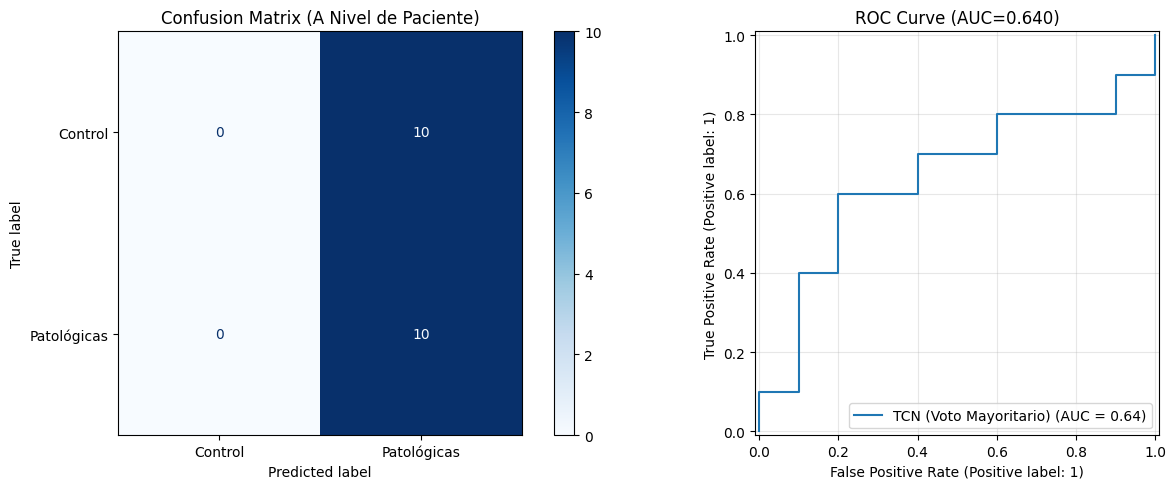

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix (A Nivel de Paciente)
cm_subj = confusion_matrix(y_true_patient, y_pred_patient)
disp_subj = ConfusionMatrixDisplay(cm_subj, display_labels=['Control', 'Patológicas'])
disp_subj.plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix (A Nivel de Paciente)')

# ROC Curve (A Nivel de Paciente)
RocCurveDisplay.from_predictions(
    y_true_patient, y_pred_proba_patient,
    name='TCN (Voto Mayoritario)',
    ax=axes[1],
)
axes[1].set_title(f'ROC Curve (AUC={roc_subj:.3f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 9. (Opcional) K-Fold Completo

Descomenta para entrenar sobre todos los folds y obtener métricas promedio.  
**⚠ Puede tardar bastante dependiendo de la duración del audio y el hardware.**

In [ ]:
# -------------------------------------------------------------------
# 10. K-FOLD CROSS VALIDATION COMPLETO (SOLO TRAIN Y TEST PURO)
# -------------------------------------------------------------------
import numpy as np
import random
import re
from sklearn.metrics import accuracy_score, roc_auc_score
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

all_accs_audio, all_aucs_audio = [], []
all_accs_subj, all_aucs_subj = [], []

def get_subject(f):
    filename = f.replace('\\', '/').split('/')[-1]
    if 'AVPEPUDEA' in filename.upper():
        return re.sub(r'[aeiou]\d+\.wav$', '', filename.lower())
    else:
        return filename.split('-')[0]

for k in range(K):
    print(f"\n{'='*70}")
    print(f" ENTRENANDO FOLD {k+1}/{K}")
    print(f"{'='*70}")
    
    fold_data = folds[k]
    train_files = fold_data['train_files']
    test_files = fold_data['test_files']
    
    # 1. CARGA DE DATOS (Train 80% vs Test 20%)
    X_train, y_train_raw = load_audio_files(train_files, DATA_DIR, TARGET_SR, TARGET_SAMPLES)
    X_test, y_test_raw = load_audio_files(test_files, DATA_DIR, TARGET_SR, TARGET_SAMPLES)
    
    y_train = to_categorical(y_train_raw, NUM_CLASSES)
    
    # 2. CREACIÓN DEL MODELO
    clf_k = TCNClassifier(
        input_shape  = (TARGET_SAMPLES,),
        n_classes    = NUM_CLASSES,
        nb_filters   = NB_FILTERS,
        kernel_size  = KERNEL_SIZE,
        dilations    = DILATIONS,
        nb_stacks    = NB_STACKS,
        dropout_rate = DROPOUT_RATE,
        dense_units  = DENSE_UNITS,
        padding      = 'causal',
    )
    clf_k.model.compile(
        optimizer = OPTIMIZER,
        loss      = tf.keras.losses.CategoricalCrossentropy(),
        metrics   = ['accuracy'],
    )
    
    # 3. ENTRENAMIENTO DIRECTO EN TODO EL 80%
    # Aquí usa el hiperparámetro EPOCHS que tengas puesto arriba
    clf_k.model.fit(
        X_train, y_train,
        epochs          = EPOCHS, 
        batch_size      = BATCH_SIZE,
        shuffle         = True,
        verbose         = 0
    )
    
    # 4. PREDICCIONES EN TEST
    y_pred_proba = clf_k.model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
    y_pred       = np.argmax(y_pred_proba, axis=1)
    y_true       = y_test_raw
    
    # Métricas por Audio
    acc_audio = accuracy_score(y_true, y_pred)
    auc_audio = roc_auc_score(y_true, y_pred_proba[:, 1])
    all_accs_audio.append(acc_audio)
    all_aucs_audio.append(auc_audio)
    
    # Métricas por Paciente
    patient_preds = {}
    patient_trues = {}
    for i, f in enumerate(test_files):
        subj = get_subject(f)
        if subj not in patient_preds:
            patient_preds[subj] = []
            patient_trues[subj] = y_true[i]
        patient_preds[subj].append(y_pred_proba[i, 1])

    y_true_patient, y_pred_patient, y_pred_proba_patient = [], [], []
    for subj in patient_preds.keys():
        y_true_patient.append(patient_trues[subj])
        mean_proba = np.mean(patient_preds[subj])
        y_pred_proba_patient.append(mean_proba)
        y_pred_patient.append(1 if mean_proba >= 0.5 else 0)

    acc_subj = accuracy_score(y_true_patient, y_pred_patient)
    auc_subj = roc_auc_score(y_true_patient, y_pred_proba_patient)
    all_accs_subj.append(acc_subj)
    all_aucs_subj.append(auc_subj)
    
    print(f"  -> Audio-Level   : Acc={acc_audio:.4f}  AUC={auc_audio:.4f}")
    print(f"  -> Subject-Level : Acc={acc_subj:.4f}  AUC={auc_subj:.4f}")

# 5. RESULTADOS FINALES PROMEDIO
print(f"\n{'='*70}")
print(f" RESULTADOS K-FOLD PROMEDIO (TEST FINAL)")
print(f"{'='*70}")
print(f" POR AUDIO (Frame-level):")
print(f"  Accuracy: {np.mean(all_accs_audio):.4f} ± {np.std(all_accs_audio):.4f}")
print(f"  ROC-AUC:  {np.mean(all_aucs_audio):.4f} ± {np.std(all_aucs_audio):.4f}")
print(f"\n POR PACIENTE (Subject-level Majority Voting):")
print(f"  Accuracy: {np.mean(all_accs_subj):.4f} ± {np.std(all_accs_subj):.4f}")
print(f"  ROC-AUC:  {np.mean(all_aucs_subj):.4f} ± {np.std(all_aucs_subj):.4f}")
